In [1]:
import tarfile, os
for name in ["ORD63177_1.tar", "ORD63177_2.tar"]:
    with tarfile.open(f"data/{name}") as tar:
        tar.extractall("data/SARAH3_raw")

C:\Users\huynh\AppData\Local\Temp\ipykernel_7556\3946061865.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("data/SARAH3_raw")


In [6]:
import os
os.listdir("data/SARAH3_raw")[:5]

['SISin2024060100000042310001I1MA.nc',
 'SISin2024060200000042310001I1MA.nc',
 'SISin2024060300000042310001I1MA.nc',
 'SISin2024060400000042310001I1MA.nc',
 'SISin2024060500000042310001I1MA.nc']

In [3]:
pip install netCDF4

Note: you may need to restart the kernel to use updated packages.


In [4]:
import xarray as xr
import os
from pathlib import Path

RAW_DIR = Path("data/SARAH3_raw")
files = sorted(str(RAW_DIR/f) for f in os.listdir(RAW_DIR) if f.endswith(".nc"))
len(files), files[:3]
# Merge efficiently (uses dask-style lazy loading under the hood)
ds = xr.open_mfdataset(files, combine="by_coords")  # auto-decodes time
print(ds)
# Key variable should be 'SIS' in W/m² (instantaneous)
ds["SIS"]
ds = xr.open_mfdataset(files, combine="by_coords", chunks={"time": 48})


<xarray.Dataset>
Dimensions:        (time: 1440, lon: 2600, bnds: 2, lat: 2600)
Coordinates:
  * time           (time) datetime64[ns] 2024-06-01 ... 2024-06-30T23:30:00
  * lon            (lon) float32 -64.97 -64.93 -64.88 ... 64.88 64.93 64.97
  * lat            (lat) float32 -64.97 -64.93 -64.88 ... 64.88 64.93 64.97
Dimensions without coordinates: bnds
Data variables:
    lon_bnds       (time, lon, bnds) float32 dask.array<chunksize=(48, 2600, 2), meta=np.ndarray>
    lat_bnds       (time, lat, bnds) float32 dask.array<chunksize=(48, 2600, 2), meta=np.ndarray>
    SIS            (time, lat, lon) float32 dask.array<chunksize=(48, 2600, 2600), meta=np.ndarray>
    record_status  (time) int8 dask.array<chunksize=(48,), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.7,ACDD-1.3
    title:                      CM SAF Surface Solar Radiation Climate Data R...
    summary:                    This file contains data from the CM SAF Surfa...
    id:                 

In [8]:
ds.lat.values[:5], ds.lat.values[-5:]


(array([-64.975, -64.925, -64.875, -64.825, -64.775], dtype=float32),
 array([64.775, 64.825, 64.875, 64.925, 64.975], dtype=float32))

In [9]:
subset = ds.sel(lat=slice(51.2, 51.8), lon=slice(4.0, 6.0))
subset

<xarray.Dataset>
Dimensions:        (time: 1440, lon: 40, bnds: 2, lat: 12)
Coordinates:
  * time           (time) datetime64[ns] 2024-06-01 ... 2024-06-30T23:30:00
  * lon            (lon) float32 4.025 4.075 4.125 4.175 ... 5.875 5.925 5.975
  * lat            (lat) float32 51.22 51.28 51.33 51.38 ... 51.67 51.72 51.78
Dimensions without coordinates: bnds
Data variables:
    lon_bnds       (time, lon, bnds) float32 dask.array<chunksize=(48, 40, 2), meta=np.ndarray>
    lat_bnds       (time, lat, bnds) float32 dask.array<chunksize=(48, 12, 2), meta=np.ndarray>
    SIS            (time, lat, lon) float32 dask.array<chunksize=(48, 12, 40), meta=np.ndarray>
    record_status  (time) int8 dask.array<chunksize=(48,), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.7,ACDD-1.3
    title:                      CM SAF Surface Solar Radiation Climate Data R...
    summary:                    This file contains data from the CM SAF Surfa...
    id:                         DOI:10.5676/EUM_SAF_CM/SARAH/V003
    product_version:            3.0
    institution:                EUMETSAT/CMSAF
    ...                         ...
    platform_vocabulary:        GCMD Platforms, Version 8.6
    platform:                   Earth Observation Satellites > METEOSAT > MET...
    instrument_vocabulary:      GCMD Instruments, Version 8.6
    instrument:                 SEVIRI > Spinning Enhanced Visible and Infrar...
    variable_id:                SIS
    license:                    The CM SAF data are owned by EUMETSAT and are...

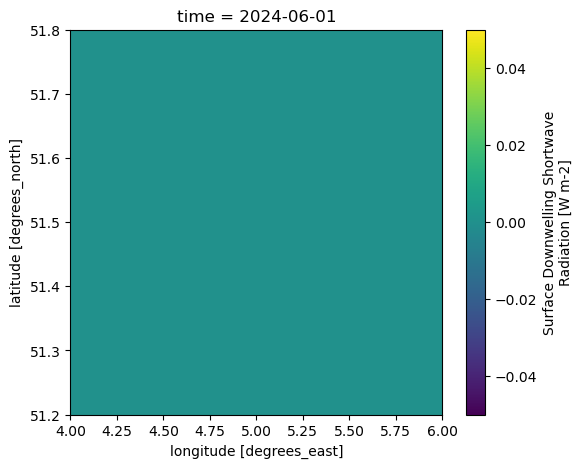

In [10]:
subset["SIS"].isel(time=0).plot(figsize=(6,5))


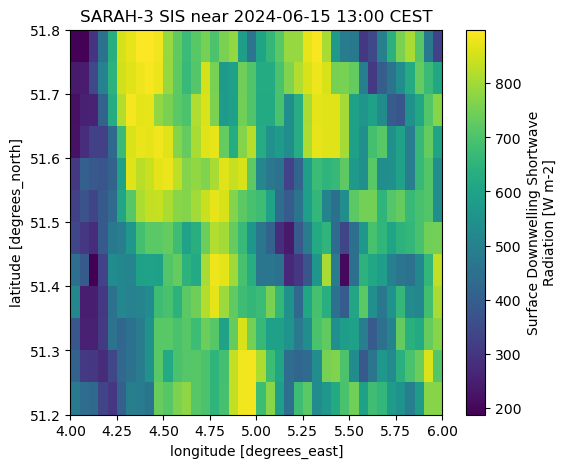

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# pick a local noon and convert to UTC
ts_local = pd.Timestamp("2024-06-15 13:00", tz="Europe/Amsterdam")
ts_utc = ts_local.tz_convert("UTC").tz_localize(None)

slice2d = subset["SIS"].sel(time=ts_utc, method="nearest")
slice2d.plot(figsize=(6,5))
plt.title(f"SARAH-3 SIS near {ts_local.strftime('%Y-%m-%d %H:%M %Z')}")
plt.show()


In [12]:
to_save = subset[["SIS"]].drop_vars(["lon_bnds","lat_bnds","record_status"], errors="ignore")

encoding = {
    "SIS": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "lat": {"dtype": "float32"},
    "lon": {"dtype": "float32"},
}

out_path = "data/SARAH3_202406_NBrabant.nc"
to_save.to_netcdf(out_path, encoding=encoding)
print("✅ Saved:", out_path, "| shape:", to_save["SIS"].shape)


✅ Saved: data/SARAH3_202406_NBrabant.nc | shape: (1440, 12, 40)


In [13]:
to_save.to_netcdf("data/SARAH3_202406_NBrabant_small.nc", encoding=encoding)

In [14]:
import xarray as xr
xr.open_dataset("data/SARAH3_202406_NBrabant.nc")

<xarray.Dataset>
Dimensions:  (time: 1440, lat: 12, lon: 40)
Coordinates:
  * time     (time) datetime64[ns] 2024-06-01 ... 2024-06-30T23:30:00
  * lon      (lon) float32 4.025 4.075 4.125 4.175 ... 5.825 5.875 5.925 5.975
  * lat      (lat) float32 51.22 51.28 51.33 51.38 ... 51.62 51.67 51.72 51.78
Data variables:
    SIS      (time, lat, lon) float32 ...
Attributes: (12/38)
    Conventions:                CF-1.7,ACDD-1.3
    title:                      CM SAF Surface Solar Radiation Climate Data R...
    summary:                    This file contains data from the CM SAF Surfa...
    id:                         DOI:10.5676/EUM_SAF_CM/SARAH/V003
    product_version:            3.0
    institution:                EUMETSAT/CMSAF
    ...                         ...
    platform_vocabulary:        GCMD Platforms, Version 8.6
    platform:                   Earth Observation Satellites > METEOSAT > MET...
    instrument_vocabulary:      GCMD Instruments, Version 8.6
    instrument:                 SEVIRI > Spinning Enhanced Visible and Infrar...
    variable_id:                SIS
    license:                    The CM SAF data are owned by EUMETSAT and are...

In [15]:
xr.open_dataset("data/SARAH3_202406_NBrabant_small.nc")

<xarray.Dataset>
Dimensions:  (time: 1440, lat: 12, lon: 40)
Coordinates:
  * time     (time) datetime64[ns] 2024-06-01 ... 2024-06-30T23:30:00
  * lon      (lon) float32 4.025 4.075 4.125 4.175 ... 5.825 5.875 5.925 5.975
  * lat      (lat) float32 51.22 51.28 51.33 51.38 ... 51.62 51.67 51.72 51.78
Data variables:
    SIS      (time, lat, lon) float32 ...
Attributes: (12/38)
    Conventions:                CF-1.7,ACDD-1.3
    title:                      CM SAF Surface Solar Radiation Climate Data R...
    summary:                    This file contains data from the CM SAF Surfa...
    id:                         DOI:10.5676/EUM_SAF_CM/SARAH/V003
    product_version:            3.0
    institution:                EUMETSAT/CMSAF
    ...                         ...
    platform_vocabulary:        GCMD Platforms, Version 8.6
    platform:                   Earth Observation Satellites > METEOSAT > MET...
    instrument_vocabulary:      GCMD Instruments, Version 8.6
    instrument:                 SEVIRI > Spinning Enhanced Visible and Infrar...
    variable_id:                SIS
    license:                    The CM SAF data are owned by EUMETSAT and are...